# BPI2019 — 04 · Insights (KPIs → cohort behaviour → SHAP)

One place to read the whole story the decoupled pipeline tells, in the order that makes it land:

1. **KPIs first** — how the purchase-to-pay process performs overall (cycle time, automation, rework, payment blocks).
2. **Cohort behaviour** — which behavioural cohort is *best* and *worst* on each KPI, and what its control-flow signature is.
3. **SHAP** — how well static context *explains* each cohort, and where it honestly cannot.

Everything is regenerated by calling the orchestrator (`../src/`); the figures are saved to `../reports/figs/`.

## 0. Setup — regenerate the results

Runs the orchestrator (raw XES → cohorts → KPIs → attribution → SHAP) and keeps everything in memory
for the plots below. Cohort numbers are deterministic (fixed seed), so the human-readable names are
stable.


In [7]:
import importlib
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

REPO = os.path.abspath(os.path.join(os.getcwd(), ".."))  # repository root (parent of notebooks/)
SRC = os.path.join(REPO, "src")
FIGS = os.path.join(REPO, "reports", "figs")
os.makedirs(FIGS, exist_ok=True)
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import data_preparation, data_modelling, orchestrator  # noqa: E401

for m in (data_preparation, data_modelling, orchestrator):
    importlib.reload(m)
from orchestrator import run_pipeline

plt.rcParams.update(
    {"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "font.size": 10}
)
sns.set_style("whitegrid")

R = run_pipeline(repo_root=REPO, k=6, force_reparse=False, weighting="balanced")

COHORT_NAMES = {
    0: "Standard P2P",
    1: "PO-deletion",
    2: "Rework / cancellations",
    3: "Short / GR-only",
    4: "High-volume service-entry",
    5: "Payment-block removed",
}
cname = lambda c: f"C{int(c)} · {COHORT_NAMES.get(int(c), '?')}"

kpis = R["cohort_kpis"].copy()
kpis.index = kpis.index.astype(int)
case_kpis = R["case_kpis"]
drivers = R["shap_drivers"].copy()
report = R["metrics"]["report"]
signature = (
    R["transitions"]
    .sort_values(["cohort", "lift"], ascending=[True, False])
    .groupby("cohort")
    .head(1)
    .set_index("cohort")["transition"]
)
print("\nready — cohorts:", {c: COHORT_NAMES[c] for c in sorted(COHORT_NAMES)})

  [prep] loaded cached parquet (set force=True to re-parse the XES)
  [prep] engineering behavioural + context features ...
  [model] clustered k=6 | silhouette 0.478 | CH 74239 | DB 1.059
  [model] XGBoost [balanced] acc 0.655 | macro-F1 0.492 | weighted-F1 0.629
  [done] 161.6s | artifacts -> <project root>\artifacts
         cohort_labels.csv, cohort_kpis.csv, cohort_path_transitions.csv,
         cohort_top_variants.csv, shap_cluster_drivers.csv, classification_report.csv,
         pipeline_summary.json

ready — cohorts: {0: 'Standard P2P', 1: 'PO-deletion', 2: 'Rework / cancellations', 3: 'Short / GR-only', 4: 'High-volume service-entry', 5: 'Payment-block removed'}


## 1. The KPIs — how the process performs overall

Before looking at *who* is fast or slow, establish the baseline: across all 251,734 purchase-to-pay
cases, what do the headline KPIs look like? Cycle time is heavily right-skewed (a few cases carry
BPI2019's known timestamp anomalies), so the median is the honest efficiency measure.


BPI Challenge 2019 — 251,734 purchase-to-pay cases
  median cycle time  : 64.0 days  (mean 72, skewed)
  automated events   : 24.1%  (share not performed by a human)
  rework rate        : 18.2%  (cancel / change / delete)
  payment-block rate : 22.2%


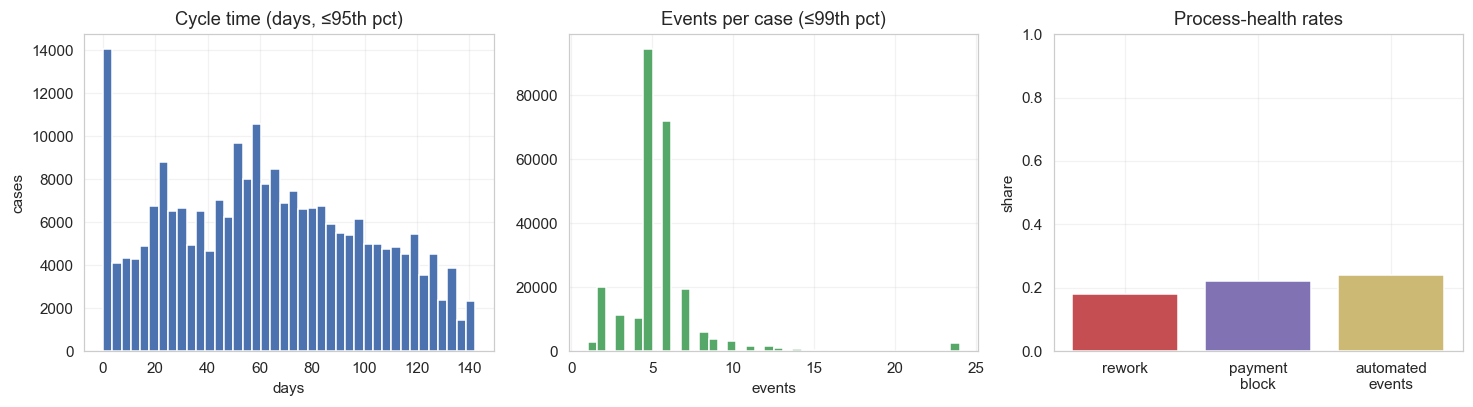

In [2]:
ck = case_kpis
print(f"BPI Challenge 2019 — {len(ck):,} purchase-to-pay cases")
print(
    f"  median cycle time  : {ck.cycle_time_days.median():.1f} days  (mean {ck.cycle_time_days.mean():.0f}, skewed)"
)
print(
    f"  automated events   : {ck.automation_ratio.mean():.1%}  (share not performed by a human)"
)
print(f"  rework rate        : {ck.is_rework.mean():.1%}  (cancel / change / delete)")
print(f"  payment-block rate : {ck.has_payment_block_removed.mean():.1%}")

fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.8))
cyc = ck.cycle_time_days.clip(lower=0)
ax[0].hist(cyc[cyc <= cyc.quantile(0.95)], bins=40, color="#4C72B0")
ax[0].set(title="Cycle time (days, ≤95th pct)", xlabel="days", ylabel="cases")
ev = ck.total_events.clip(upper=ck.total_events.quantile(0.99))
ax[1].hist(ev, bins=40, color="#55A868")
ax[1].set(title="Events per case (≤99th pct)", xlabel="events")
rates = {
    "rework": ck.is_rework.mean(),
    "payment\nblock": ck.has_payment_block_removed.mean(),
    "automated\nevents": ck.automation_ratio.mean(),
}
ax[2].bar(list(rates), list(rates.values()), color=["#C44E52", "#8172B3", "#CCB974"])
ax[2].set(title="Process-health rates", ylabel="share", ylim=(0, 1))
fig.tight_layout()
fig.savefig(os.path.join(FIGS, "01_kpi_overview.png"), bbox_inches="tight")
plt.show()

## 2. Cohort behaviour — best & worst per KPI

The behavioural clustering splits the log into six cohorts. Now benchmark them: for each KPI, which
cohort is the *reference* (best) and which is the *laggard* (worst), and what control-flow signature
sets them apart. In the heatmap **red = worse** on that KPI (automation is inverted so low automation
is red); annotations are the actual values.


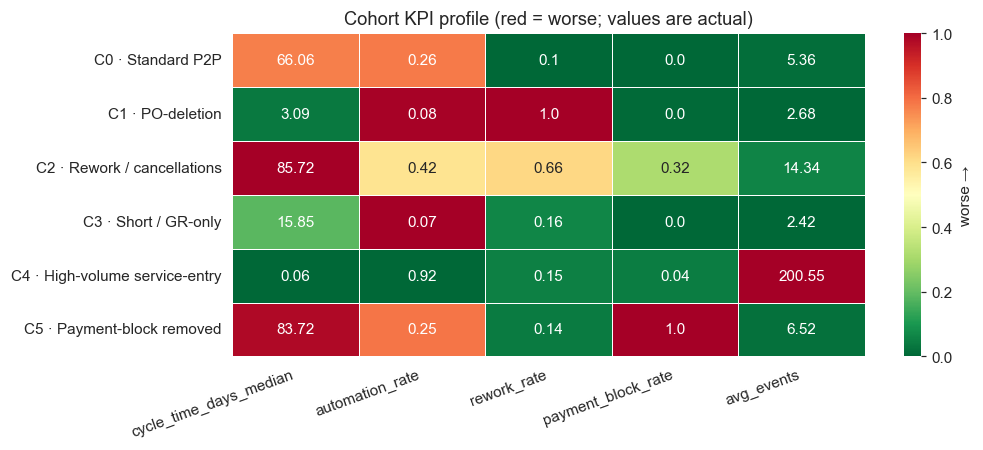

In [8]:
metric_cols = [
    "cycle_time_days_median",
    "automation_rate",
    "rework_rate",
    "payment_block_rate",
    "avg_events",
]
orient = {
    "cycle_time_days_median": 1,
    "automation_rate": -1,
    "rework_rate": 1,
    "payment_block_rate": 1,
    "avg_events": 1,
}  # +1: higher is worse, -1: higher is better

kd = kpis.loc[sorted(kpis.index), metric_cols].copy()
kd.index = [cname(c) for c in kd.index]
Zbad = pd.DataFrame(index=kd.index)
for c, d in orient.items():
    col = kd[c] * d
    Zbad[c] = (col - col.min()) / (col.max() - col.min() + 1e-9)

fig, ax = plt.subplots(figsize=(9.5, 4.2))
sns.heatmap(
    Zbad,
    annot=kd.round(2).values,
    fmt="",
    cmap="RdYlGn_r",
    linewidths=0.5,
    cbar_kws={"label": "worse →"},
    ax=ax,
)
ax.set(
    title="Cohort KPI profile (red = worse; values are actual)", xlabel="", ylabel=""
)
plt.xticks(rotation=20, ha="right")
fig.tight_layout()
fig.savefig(os.path.join(FIGS, "02_cohort_kpi_heatmap.png"), bbox_inches="tight")
plt.show()

In [9]:
# best (reference) & worst (laggard) cohort per KPI, with its control-flow signature
directions = {
    "cycle_time_days_median": ("cycle time (days)", False),  # lower is better
    "automation_rate": ("automation", True),  # higher is better
    "rework_rate": ("rework rate", False),
    "payment_block_rate": ("payment-block rate", False),
}
for col, (label, higher_better) in directions.items():
    s = kpis[col]
    best = int(s.idxmax() if higher_better else s.idxmin())
    worst = int(s.idxmin() if higher_better else s.idxmax())
    print(f"■ {label}")
    print(f"    BEST   {cname(best):26s} {s[best]:8.3f}   ↳ {signature.get(best, '—')}")
    print(
        f"    WORST  {cname(worst):26s} {s[worst]:8.3f}   ↳ {signature.get(worst, '—')}\n"
    )

print("Top trace variant for the two laggard cohorts (rework & payment-block):")
for c in (2, 5):
    v = R["variants"][R["variants"].cohort == c].iloc[0]
    print(
        f"  {cname(c)}  ({v['pct']}% of cohort): {v['variant'][:120]}{'…' if len(v['variant'])>120 else ''}"
    )

■ cycle time (days)
    BEST   C4 · High-volume service-entry    0.058   ↳ Record Service Entry Sheet -> Record Service Entry Sheet
    WORST  C2 · Rework / cancellations   85.719   ↳ Record Service Entry Sheet -> Record Goods Receipt

■ automation
    BEST   C4 · High-volume service-entry    0.915   ↳ Record Service Entry Sheet -> Record Service Entry Sheet
    WORST  C3 · Short / GR-only          0.074   ↳ Create Purchase Order Item -> Record Goods Receipt

■ rework rate
    BEST   C0 · Standard P2P             0.105   ↳ Record Invoice Receipt -> Clear Invoice
    WORST  C1 · PO-deletion              1.000   ↳ Create Purchase Order Item -> Delete Purchase Order Item

■ payment-block rate
    BEST   C0 · Standard P2P             0.000   ↳ Record Invoice Receipt -> Clear Invoice
    WORST  C5 · Payment-block removed    1.000   ↳ Record Goods Receipt -> Remove Payment Block

Top trace variant for the two laggard cohorts (rework & payment-block):
  C2 · Rework / cancellations  (1.9% of c

## 3. SHAP — how static context explains the cohorts

The cohorts are defined by *behaviour*. The decoupled method now asks: can the *excluded* static
context (item category, spend area, decile-binned value, …) explain **why** a case lands in each
cohort? For each cohort we keep the correctly-classified cases, take their SHAP toward the cohort,
and rank the **feature–value pairs** with the highest positive mean SHAP that cover at least 20 % of
the cohort — i.e. *which specific context values push cases into the cohort*. The per-class F1 then
shows where context genuinely explains the cohort and where it cannot.


In [10]:
# per-cohort feature-value drivers: which specific context values push cases into each cohort
# (correctly-classified cases; positive mean SHAP; value present in >=20% of the cohort)
from IPython.display import display

tbl = drivers.copy()
tbl["driver"] = tbl.feature.str.replace("_", " ") + " = " + tbl.value.astype(str)
tbl["cohort"] = tbl.cohort.map(cname)
show = tbl[["cohort", "rank", "driver", "mean_shap", "cohort_pct"]].rename(
    columns={"mean_shap": "mean SHAP", "cohort_pct": "% of cohort"}
)
display(
    show.style.hide(axis="index").format(
        {"mean SHAP": "{:.3f}", "% of cohort": "{:.0f}%"}
    )
)

cohort,rank,driver,mean SHAP,% of cohort
C0 · Standard P2P,1,sub spend area = Products for Resale,0.177,33%
C0 · Standard P2P,2,item type = Standard,0.155,96%
C0 · Standard P2P,3,sub spend area = Labels,0.080,27%
C0 · Standard P2P,4,spend area = Sales,0.036,35%
C0 · Standard P2P,5,spend classification = PR,0.024,61%
C0 · Standard P2P,6,"item category = 3-way match, invoice before GR",0.013,96%
C1 · PO-deletion,1,"case value band = D9 (€2,481–€5,951)",0.856,22%
C1 · PO-deletion,2,"case value band = D10 (€5,951–€26,788,948)",0.665,21%
C1 · PO-deletion,3,"case value band = D8 (€1,227–€2,481)",0.643,21%
C1 · PO-deletion,4,sub spend area = Trading products (old structure),0.533,44%


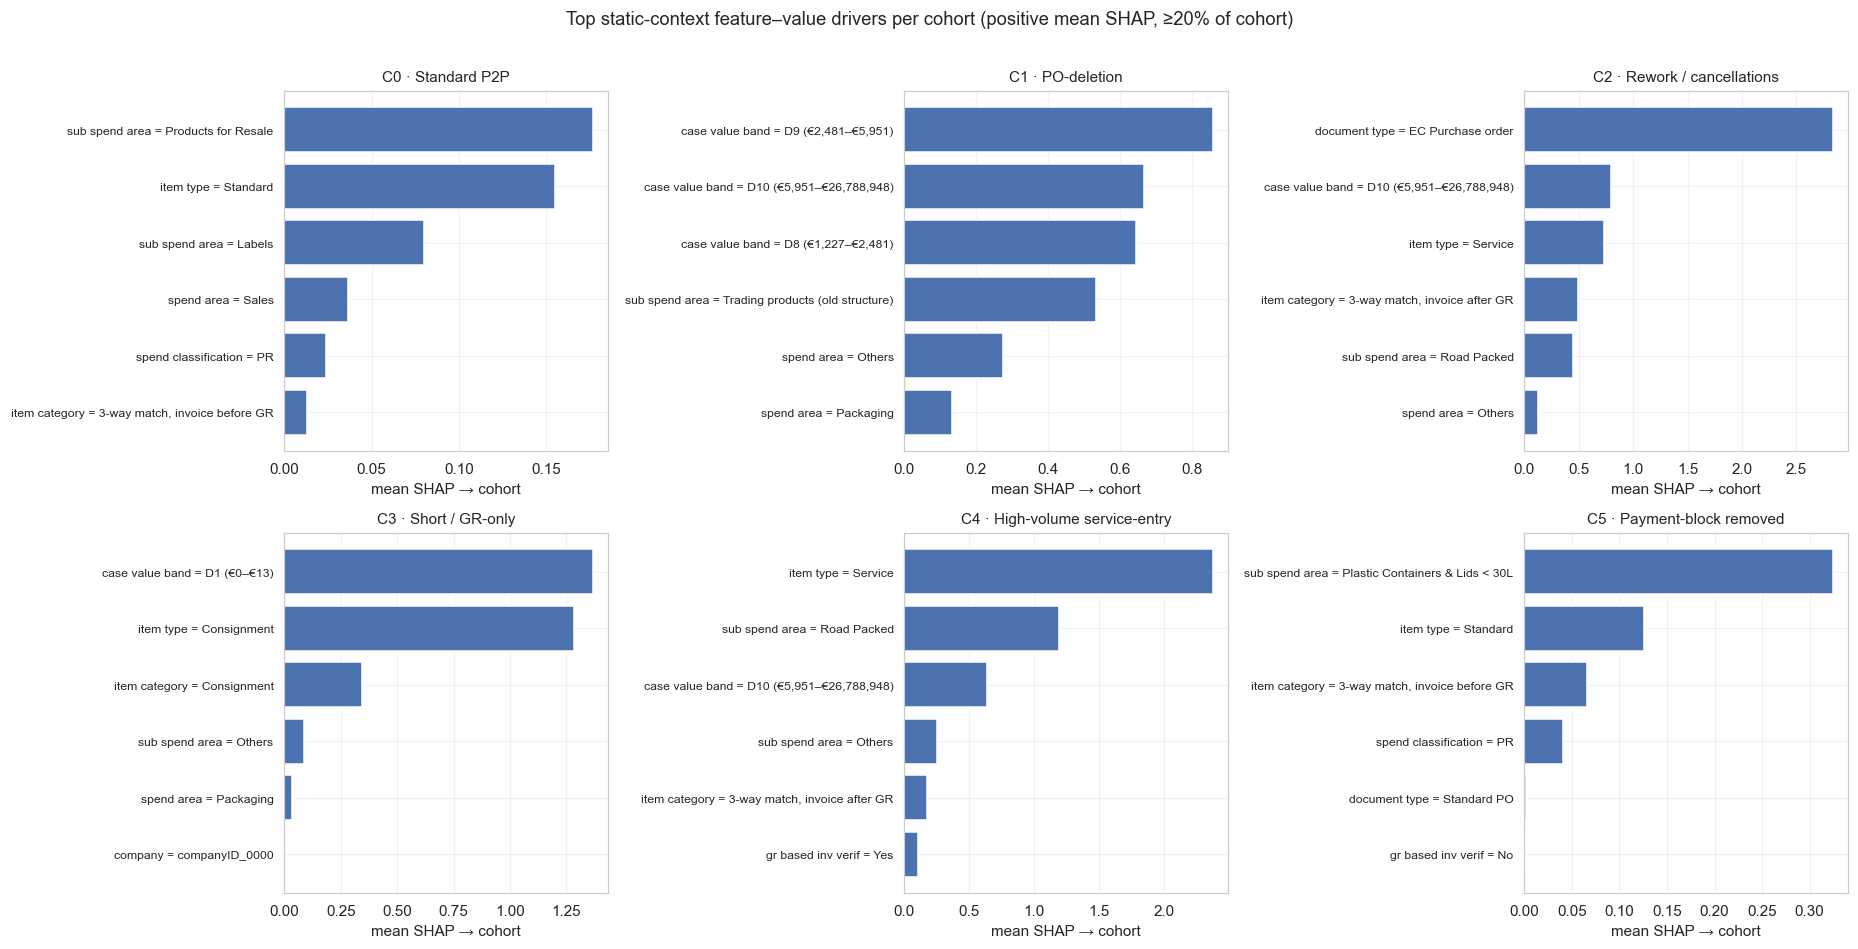

In [11]:
# per-cohort feature-value drivers (bar length = mean SHAP toward the cohort for that specific
# context value; longer = that value pushes cases into the cohort more strongly)
order = sorted(drivers.cohort.unique())
fig, axes = plt.subplots(2, 3, figsize=(17, 8.5))
for ax, c in zip(axes.ravel(), order):
    d = drivers[drivers.cohort == c].sort_values("mean_shap")
    labels = [f"{f.replace('_', ' ')} = {v}" for f, v in zip(d.feature, d.value)]
    ax.barh(labels, d.mean_shap, color="#4C72B0")
    ax.set_title(cname(c), fontsize=10)
    ax.set_xlabel("mean SHAP → cohort")
    ax.tick_params(axis="y", labelsize=8)
for ax in axes.ravel()[len(order) :]:
    ax.axis("off")
fig.suptitle(
    "Top static-context feature–value drivers per cohort (positive mean SHAP, ≥20% of cohort)",
    y=1.01,
)
fig.tight_layout()
fig.savefig(os.path.join(FIGS, "03_shap_cohort_drivers.png"), bbox_inches="tight")
plt.show()

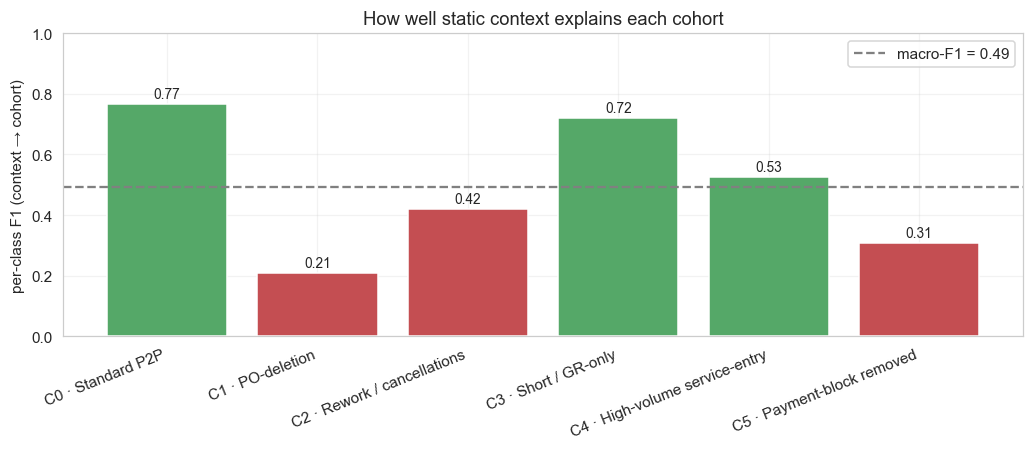

Read-out: structural cohorts (Standard, Short/GR-only) are well explained by context; the
rework / payment-block / PO-deletion cohorts are not — going into rework or a payment block is
an execution phenomenon, not something the static procurement context determines. That gap is
exactly why clustering on behaviour adds information beyond context alone.


In [12]:
# reliability: how well does context explain each cohort? (per-class F1 of context -> cohort)
cls_ids = [str(c) for c in order]
f1s = [report[c]["f1-score"] for c in cls_ids]
macro = report["macro avg"]["f1-score"]

fig, ax = plt.subplots(figsize=(9.5, 4.2))
bars = ax.bar(
    [cname(int(c)) for c in cls_ids],
    f1s,
    color=["#55A868" if v >= macro else "#C44E52" for v in f1s],
)
ax.axhline(macro, color="grey", ls="--", label=f"macro-F1 = {macro:.2f}")
ax.set(
    title="How well static context explains each cohort",
    ylabel="per-class F1 (context → cohort)",
    ylim=(0, 1),
)
for b, v in zip(bars, f1s):
    ax.text(
        b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.2f}", ha="center", fontsize=9
    )
plt.xticks(rotation=22, ha="right")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIGS, "04_context_reliability.png"), bbox_inches="tight")
plt.show()

print(
    "Read-out: structural cohorts (Standard, Short/GR-only) are well explained by context; the"
)
print(
    "rework / payment-block / PO-deletion cohorts are not — going into rework or a payment block is"
)
print(
    "an execution phenomenon, not something the static procurement context determines. That gap is"
)
print("exactly why clustering on behaviour adds information beyond context alone.")

## 4. The story in one paragraph

Overall the purchase-to-pay process is a mostly-standard 3-way-match flow with a long right tail.
Behavioural clustering separates a clean **reference** flow (Standard P2P, Short/GR-only) from
**laggard** cohorts that drag the KPIs: a *payment-block* cohort (compliance drag), a *rework /
cancellation* cohort (quality drag, longest cycle time and most rework), and an early *PO-deletion*
cohort. Attributing those cohorts back to the excluded static context shows a clear split: the
structural cohorts are well explained by procurement context (item category, value, spend area),
while the rework and payment-block cohorts are **not** — their fate is decided at execution time, not
by their static context. That is the core benchmarking insight: context tells you *what kind of
purchase* a case is, but behaviour is what reveals *how it actually ran* — and the two only partly
overlap, which is precisely why decoupling them is worthwhile.
